In [1]:
#Import libraries and tools required for feature extraction and model evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score 

#Class imbalance
from imblearn.over_sampling import SMOTE

In [2]:
#Load the clean dataset
df = pd.read_csv('../Data/cleaned_data.csv')

print('shape:', df.shape)
print('Fraud%:', round(df['fraudulent'].mean() * 100,2))
df.head()

shape: (17880, 8)
Fraud%: 4.84


,cleaned_text,telecommuting,has_company_logo,has_questions,has_company_profile,has_requirements,has_benefits,fraudulent
0,marketing intern food created groundbreaking a...,0,1,0,1,1,0,0
1,customer service cloud video production second...,0,1,0,1,1,1,0
2,commissioning machinery assistant cma valor se...,0,1,0,1,1,0,0
3,account executive washington passion improving...,0,1,0,1,1,1,0
4,bill review manager spotsource solution llc gl...,0,1,1,1,1,1,0


In [3]:
#Separate the text features from the target variable
X_text = df['cleaned_text'].fillna('')
y = df['fraudulent']

#The 6 binary columns
metadata_cols = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'has_company_profile',
    'has_requirements',
    'has_benefits'
]
X_meta = df[metadata_cols].fillna(0).values

#Split the text, metadata and target into training and test sets
X_text_train, X_text_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text, X_meta, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#TF-IDF fitted on the training text 
#Use unigrams and bigrams to capture both individual words and short phrases
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test = tfidf.transform(X_text_test)

#Combine the TF-IDF features with the metadata features
X_train = hstack([X_tfidf_train, csr_matrix(X_meta_train)]).tocsr()
X_test = hstack([X_tfidf_test, csr_matrix(X_meta_test)]).tocsr()


print('TF-IDF features:', X_tfidf_train.shape[1])
print('Metadata features:', X_meta.shape[1])
print('Train matrix:', X_train.shape, 'Test matrix:', X_test.shape)

TF-IDF features: 5000
Metadata features: 6
Train matrix: (14304, 5006) Test matrix: (3576, 5006)


In [4]:
#Display the number of observations
print('Training set:', X_train.shape[0], 'rows')
print('Test set:', X_test.shape[0], 'rows')
print('Fraud % in train:', round(y_train.mean() * 100, 2))
print('Fraud % in test:', round(y_test.mean() * 100, 2))

Training set: 14304 rows
Test set: 3576 rows
Fraud % in train: 4.84
Fraud % in test: 4.84


In [5]:
#Train the baseline Logistic Regression
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)

#Predict on test set
y_pred_baseline = lr_baseline.predict(X_test)
y_prob_baseline = lr_baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_baseline, target_names=['Real (0)', 'Fraud (1)']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_baseline), 4))


              precision    recall  f1-score   support

    Real (0)       0.97      1.00      0.99      3403
   Fraud (1)       0.99      0.45      0.61       173

    accuracy                           0.97      3576
   macro avg       0.98      0.72      0.80      3576
weighted avg       0.97      0.97      0.97      3576

AUC-ROC: 0.9812


In [6]:
#Train Logistic Regression with class weighting
lr_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_weighted.fit(X_train, y_train)

y_pred_weighted = lr_weighted.predict(X_test)
y_prob_weighted = lr_weighted.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_weighted, target_names=['Real (0)', 'Fraud (1)']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_weighted), 4))

              precision    recall  f1-score   support

    Real (0)       1.00      0.96      0.98      3403
   Fraud (1)       0.54      0.91      0.68       173

    accuracy                           0.96      3576
   macro avg       0.77      0.94      0.83      3576
weighted avg       0.97      0.96      0.96      3576

AUC-ROC: 0.9886


In [7]:
#Apply SMOTE to balance the classes in the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', pd.Series(y_train).value_counts().to_dict())
print('After SMOTE:', pd.Series(y_train_smote).value_counts().to_dict())

#Train Logistic Regression using the SMOTE-balanced training data
lr_smote = LogisticRegression(max_iter=1000,random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test)
y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

print()
print(classification_report(y_test, y_pred_smote, target_names=['Real (0)', 'Fraud (1)']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_smote), 4))


Before SMOTE: {0: 13611, 1: 693}
After SMOTE: {0: 13611, 1: 13611}

              precision    recall  f1-score   support

    Real (0)       0.99      0.98      0.98      3403
   Fraud (1)       0.65      0.90      0.75       173

    accuracy                           0.97      3576
   macro avg       0.82      0.94      0.87      3576
weighted avg       0.98      0.97      0.97      3576

AUC-ROC: 0.9898


In [8]:
#Compare the performance of the three Logistic Regression models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, y_prob, name):
    return{
        'Model': name,
        'Accuracy %': round(accuracy_score(y_true, y_pred) * 100, 2),
        'Fraud Precision %': round(precision_score(y_true, y_pred) * 100, 2),
        'Fraud Recall %': round(recall_score(y_true, y_pred) *100, 2),
        'Fraud F1 %': round(f1_score(y_true, y_pred) * 100, 2),
        'AUC-ROC': round(roc_auc_score(y_true, y_prob), 4)

    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_baseline, y_prob_baseline, 'LR - Baseline'),
    get_metrics(y_test, y_pred_weighted, y_prob_weighted, 'LR - Class Weighting'),
    get_metrics(y_test, y_pred_smote, y_prob_smote, 'LR - SMOTE'),
])

print(results.to_string(index=False))

results.to_csv('../Output/lr_comparison.csv', index=False)

               Model  Accuracy %  Fraud Precision %  Fraud Recall %  Fraud F1 %  AUC-ROC
       LR - Baseline       97.29              98.72           44.51       61.35   0.9812
LR - Class Weighting       95.83              54.11           91.33       67.96   0.9886
          LR - SMOTE       97.15              64.85           89.60       75.24   0.9898


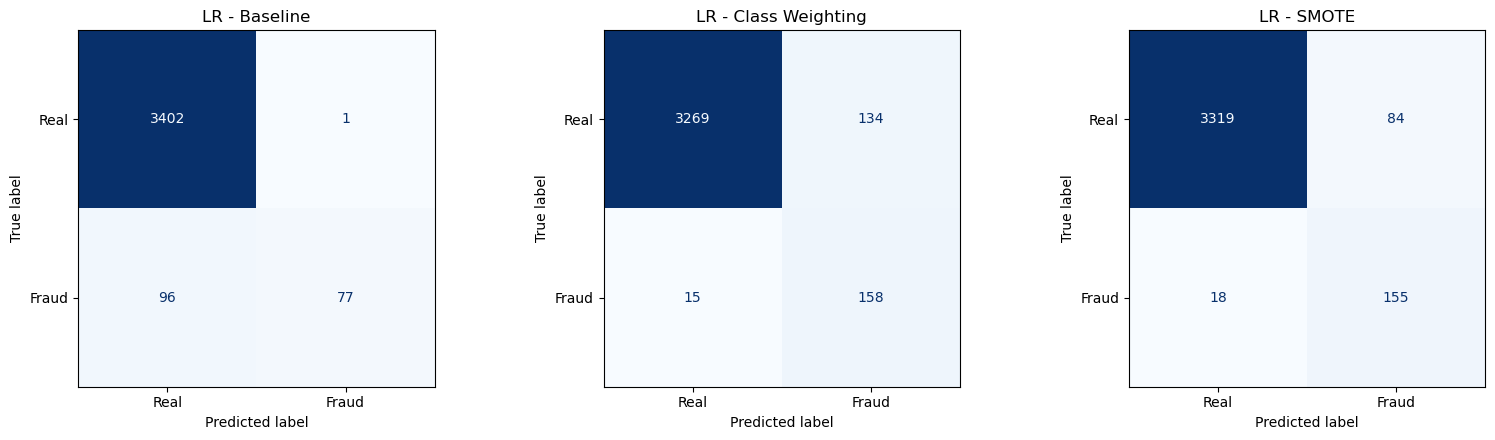

In [9]:
#Confusion matrices to compare classification errors across the models
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, preds, title in[
    (axes[0], y_pred_baseline, 'Baseline'),
    (axes[1], y_pred_weighted, 'Class Weighting'),
    (axes[2], y_pred_smote, 'SMOTE')
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=['Real', 'Fraud'], cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'LR - {title}')

plt.tight_layout()
plt.savefig('../Output/lr_confusion_matrices.png',dpi=150, bbox_inches='tight')
plt.show()

In [10]:
from sklearn.metrics import f1_score
#Overfitting check

print('Train F1:', round(f1_score(y_train, lr_weighted.predict(X_train)), 4))
print('Test F1:', round(f1_score(y_test, y_pred_weighted), 4))

Train F1: 0.7368
Test F1: 0.6796


## Findings

- **Baseline:** Approximately 97% accuracy but only 44.51% fraud recall, showing that accuracy alone is misleading for this imbalanced dataset

- **Class weighting:** Fraud recall increases substantially to 91.33% but precision decreases to 54.11%, resulting in more false positives

- **SMOTE:** Achieves 89.60% fraud recall, 75.24% fraud F1 and an AUC-ROC of 0.9898

- Among the three Logistic Regression configurations, SMOTE provides the strongest F1 performance while class weighting provides the highest fraud recall.

- AUC > 0.98 in all three, so the fraud probability score is reliable for the prototype